In [139]:
import pandas as pd
import numpy as np
import geohash2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE

def get_distance_by_haversine(pick_lat, pick_lon, drop_lat, drop_lon):
    earth_radius = 6371
    pick_lat, pick_lon, drop_lat, drop_lon = map(np.radians,[pick_lat, pick_lon, drop_lat, drop_lon])
    lat = drop_lat - pick_lat
    lon = drop_lon - pick_lon
    a = np.sin(lat / 2) ** 2 + \
        np.cos(pick_lat) * np.cos(drop_lat) * np.sin(lon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius*c

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean
    
trip_fare_pd = pd.read_csv("taxi_fare.csv")

trip_fare_pd['pickup_datetime'] = pd.to_datetime(trip_fare_pd['tpep_pickup_datetime'])
trip_fare_pd['dropoff_datetime'] = pd.to_datetime(trip_fare_pd['tpep_dropoff_datetime'])
trip_fare_pd['distance_km'] = get_distance_by_haversine(trip_fare_pd['pickup_latitude'],trip_fare_pd['pickup_longitude'],trip_fare_pd['dropoff_latitude'],trip_fare_pd['dropoff_longitude'])
trip_fare_pd['time_taken'] = (trip_fare_pd['dropoff_datetime'] - trip_fare_pd['pickup_datetime']).dt.total_seconds() / 60
trip_fare_pd['hour_of_the_day'] = trip_fare_pd['pickup_datetime'].dt.hour
trip_fare_pd['day_of_week'] = trip_fare_pd['pickup_datetime'].dt.dayofweek
trip_fare_pd['is_weekend'] = trip_fare_pd['day_of_week'].isin([5,6]).astype(int)
trip_fare_pd['is_peak_hour'] = trip_fare_pd['hour_of_the_day'].apply(lambda x: 1 if (7 <= x < 10) or (16 <= x < 19) else 0)
trip_fare_pd['is_late_night_or_early_morning'] = trip_fare_pd['hour_of_the_day'].apply(lambda x: 1 if (0 <= x < 6) or (22 <= x <= 23) else 0)
trip_fare_pd['pickup_zone'] = trip_fare_pd.apply(lambda x: geohash2.encode(x['pickup_latitude'], x['pickup_longitude'], precision=5), axis=1)
trip_fare_pd['dropoff_zone'] = trip_fare_pd.apply(lambda x: geohash2.encode(x['dropoff_latitude'], x['dropoff_longitude'], precision=5), axis=1)
trip_fare_pd['zone_pair'] = trip_fare_pd['pickup_zone'] + "_" + trip_fare_pd['dropoff_zone']

final_columns = [
    'distance_km', 'time_taken', 'passenger_count', 'hour_of_the_day', 'day_of_week',
    'is_peak_hour', 'is_weekend', 'is_late_night_or_early_morning',
    'pickup_zone', 'dropoff_zone', 'zone_pair',
    'RatecodeID', 'extra', 'mta_tax', 'fare_amount'
]

feature_df = trip_fare_pd[final_columns]

In [140]:
feature_df.isnull().sum()

distance_km                       0
time_taken                        0
passenger_count                   0
hour_of_the_day                   0
day_of_week                       0
is_peak_hour                      0
is_weekend                        0
is_late_night_or_early_morning    0
pickup_zone                       0
dropoff_zone                      0
zone_pair                         0
RatecodeID                        0
extra                             0
mta_tax                           0
fare_amount                       0
dtype: int64

In [141]:
#There are no empty values
feature_df.duplicated().sum()

np.int64(23)

In [142]:
#There are 23 duplicate rows
#Remove those identical rows
feature_df = feature_df.drop_duplicates()
feature_df.duplicated().sum()

np.int64(0)

In [143]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212322 entries, 0 to 212344
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_km                     212322 non-null  float64
 1   time_taken                      212322 non-null  float64
 2   passenger_count                 212322 non-null  int64  
 3   hour_of_the_day                 212322 non-null  int32  
 4   day_of_week                     212322 non-null  int32  
 5   is_peak_hour                    212322 non-null  int64  
 6   is_weekend                      212322 non-null  int64  
 7   is_late_night_or_early_morning  212322 non-null  int64  
 8   pickup_zone                     212322 non-null  object 
 9   dropoff_zone                    212322 non-null  object 
 10  zone_pair                       212322 non-null  object 
 11  RatecodeID                      212322 non-null  int64  
 12  extra                

In [144]:
feature_df.describe()

,distance_km,time_taken,passenger_count,hour_of_the_day,day_of_week,is_peak_hour,is_weekend,is_late_night_or_early_morning,RatecodeID,extra,mta_tax,fare_amount
count,212322.000000,212322.000000,212322.000000,212322.000000,212322.000000,212322.000000,212322.0,212322.000000,212322.000000,212322.000000,212322.000000,212322.000000
mean,25.159332,16.151031,1.766553,8.732934,1.770311,0.435160,0.0,0.100385,1.034113,0.048080,0.497666,12.665592
std,435.591299,56.181479,1.469677,3.102466,0.973266,0.495779,0.0,0.300514,0.494571,0.148107,0.037407,10.874614
min,0.000000,-7174.583333,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,1.000000,-0.500000,-0.500000,-52.000000
25%,1.155415,6.716667,1.000000,7.000000,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.500000,6.500000
50%,1.937854,11.266667,1.000000,9.000000,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.500000,9.500000
75%,3.565745,18.300000,2.000000,11.000000,3.000000,1.000000,0.0,0.000000,1.000000,0.000000,0.500000,14.500000
max,8713.463111,1439.383333,6.000000,14.000000,3.000000,1.000000,0.0,1.000000,99.000000,4.500000,0.500000,819.500000


In [145]:
#Remove rows where passenger_count is 0
feature_df = feature_df[feature_df['passenger_count'] > 0]
#Remove rows where distance is less than 50 meters
feature_df = feature_df[feature_df['distance_km']>0.05]
#Remove rows where time is less than 60 seconds
feature_df = feature_df[feature_df['time_taken']> 1]
len(feature_df)
#Remove rows with negative fare amount
feature_df = feature_df[feature_df['fare_amount']> 0]
#Remove Outliers
outlier_check_cols = ['distance_km', 'time_taken', 'fare_amount', 'extra', 'mta_tax']
feature_df_clean = remove_outliers_iqr(feature_df, outlier_check_cols)
#Fix Skewed Values using Log Transformation
feature_df_clean['log_distance'] = np.log1p(feature_df_clean['distance_km'])
feature_df_clean['log_fare'] = np.log1p(feature_df_clean['fare_amount'])
feature_df_clean['log_time'] = np.log1p(feature_df_clean['time_taken'])
#Encoding
le = LabelEncoder()
feature_df_clean['RateCodeID_enc'] = le.fit_transform(feature_df_clean['RatecodeID'])
feature_df_clean = pd.get_dummies(feature_df_clean, columns=['pickup_zone', 'dropoff_zone'], drop_first=True)

feature_cols = [
    'log_distance', 'log_time', 'passenger_count', 'hour_of_the_day',
    'day_of_week', 'is_peak_hour', 'is_weekend', 'is_late_night_or_early_morning',
    'extra', 'mta_tax', 'RateCodeID_enc'
]
zone_cols = [col for col in feature_df_clean.columns if col.startswith('pickup_zone_') or col.startswith('dropoff_zone_')]
feature_cols += zone_cols
X = feature_df_clean[feature_cols]
y = feature_df_clean['log_fare'] 

#Random Forest Feature Selection
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=False)

print("Top 20 features by Random Forest importance:")
print(rf_importances.head(20))


Top 20 features by Random Forest importance:
log_time              0.922796
log_distance          0.067990
hour_of_the_day       0.002218
passenger_count       0.000891
dropoff_zone_dr5re    0.000569
day_of_week           0.000515
pickup_zone_dr5rs     0.000466
dropoff_zone_dr5ru    0.000447
pickup_zone_dr5ru     0.000444
dropoff_zone_dr5rs    0.000358
pickup_zone_dr5rv     0.000323
pickup_zone_dr5re     0.000312
is_peak_hour          0.000300
dropoff_zone_dr5rv    0.000233
dropoff_zone_dr72j    0.000226
dropoff_zone_dr72h    0.000219
pickup_zone_dr72h     0.000210
pickup_zone_dr72j     0.000152
pickup_zone_dr5x1     0.000145
RateCodeID_enc        0.000126
dtype: float64


In [147]:
from sklearn.feature_selection import mutual_info_regression
numeric_features = ['log_distance', 'log_time', 'passenger_count', 'hour_of_the_day', 
                    'day_of_week', 'extra', 'mta_tax']
mi_scores = mutual_info_regression(feature_df_clean[numeric_features], y)
mi_df = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)

print("\nMutual Information scores for numeric features:")
print(mi_df)


Mutual Information scores for numeric features:
log_time           1.504765
log_distance       0.645697
hour_of_the_day    0.001695
passenger_count    0.001381
extra              0.001189
day_of_week        0.000000
mta_tax            0.000000
dtype: float64


In [148]:
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=15)
rfe_selector.fit(X, y)

selected_features_rfe = X.columns[rfe_selector.support_]
print("\nTop 15 features selected by RFE:")
print(selected_features_rfe)


Top 15 features selected by RFE:
Index(['log_distance', 'log_time', 'passenger_count', 'hour_of_the_day',
       'day_of_week', 'is_peak_hour', 'pickup_zone_dr5re', 'pickup_zone_dr5rs',
       'pickup_zone_dr5ru', 'pickup_zone_dr5rv', 'dropoff_zone_dr5re',
       'dropoff_zone_dr5rs', 'dropoff_zone_dr5ru', 'dropoff_zone_dr72h',
       'dropoff_zone_dr72j'],
      dtype='object')


In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    }
    
features = [
    'log_time', 'log_distance',          
    'hour_of_the_day',                    
    'passenger_count', 'day_of_week'          
]

X_df = feature_df_clean[features]
Y_df = feature_df_clean['log_fare']

X_train, X_test, y_train, y_test = train_test_split(X_df,Y_df, test_size=0.2, random_state=42)

In [150]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_results = evaluate_model(lr, X_test, y_test)
lr_results

{'R2': 0.9705405798170985,
 'MSE': 0.004043007590766634,
 'RMSE': np.float64(0.06358464901819176),
 'MAE': 0.04509699549958708}

In [151]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_results = evaluate_model(ridge, X_test, y_test)
ridge_results

{'R2': 0.9705405535737003,
 'MSE': 0.004043011192407725,
 'RMSE': np.float64(0.06358467733980983),
 'MAE': 0.04509698277624762}

In [152]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

lasso_results = evaluate_model(lasso, X_test, y_test)
lasso_results

{'R2': 0.9704682098633782,
 'MSE': 0.00405293963526778,
 'RMSE': np.float64(0.06366270207325307),
 'MAE': 0.04507337774056817}

In [154]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_results = evaluate_model(rf, X_test, y_test)
rf_results

{'R2': 0.9805636220495391,
 'MSE': 0.002667446375483384,
 'RMSE': np.float64(0.05164732689581702),
 'MAE': 0.03412087490955568}

In [155]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_results = evaluate_model(gbr, X_test, y_test)
gbr_results

{'R2': 0.9814958599862378,
 'MSE': 0.002539506143426105,
 'RMSE': np.float64(0.05039351291015645),
 'MAE': 0.033974889231019316}

In [156]:
results_df = pd.DataFrame.from_dict({
    "Linear Regression": lr_results,
    "Ridge": ridge_results,
    "Lasso": lasso_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gbr_results
}, orient='index')

results_df

,R2,MSE,RMSE,MAE
Linear Regression,0.970541,0.004043,0.063585,0.045097
Ridge,0.970541,0.004043,0.063585,0.045097
Lasso,0.970468,0.004053,0.063663,0.045073
Random Forest,0.980564,0.002667,0.051647,0.034121
Gradient Boosting,0.981496,0.002540,0.050394,0.033975


In [157]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}
gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [159]:
best_gbr = grid_search.best_estimator_
best_gbr.fit(X_train, y_train)
tuned_results = evaluate_model(best_gbr, X_test, y_test)
tuned_results

{'R2': 0.9816699805236173,
 'MSE': 0.002515609859997463,
 'RMSE': np.float64(0.05015585569001353),
 'MAE': 0.033710114399974025}

In [160]:
comparison_df = pd.DataFrame({
    'Before Tuning': gbr_results,
    'After Tuning': tuned_results
})

comparison_df

,Before Tuning,After Tuning
R2,0.981496,0.981670
MSE,0.002540,0.002516
RMSE,0.050394,0.050156
MAE,0.033975,0.033710


In [161]:
import joblib
joblib.dump(best_gbr, "gradient_boosting_taxi_fare_model.joblib")

['gradient_boosting_taxi_fare_model.joblib']

**EDA**

In [164]:
feature_df.columns

Index(['distance_km', 'time_taken', 'passenger_count', 'hour_of_the_day',
       'day_of_week', 'is_peak_hour', 'is_weekend',
       'is_late_night_or_early_morning', 'pickup_zone', 'dropoff_zone',
       'zone_pair', 'RatecodeID', 'extra', 'mta_tax', 'fare_amount'],
      dtype='object')

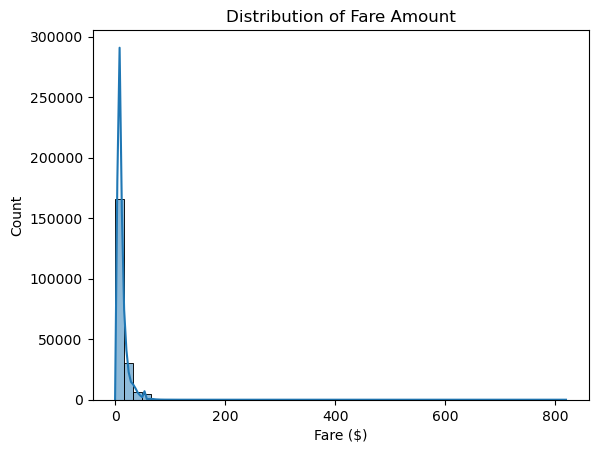

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.histplot(feature_df['fare_amount'], bins=50, kde=True)
plt.title("Distribution of Fare Amount")
plt.xlabel("Fare ($)")
plt.show()

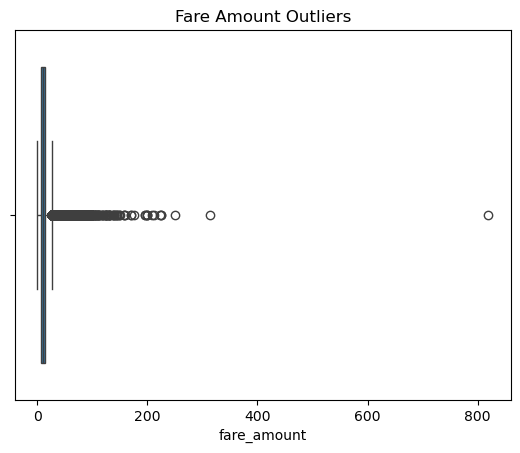

In [173]:
sns.boxplot(x=feature_df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()

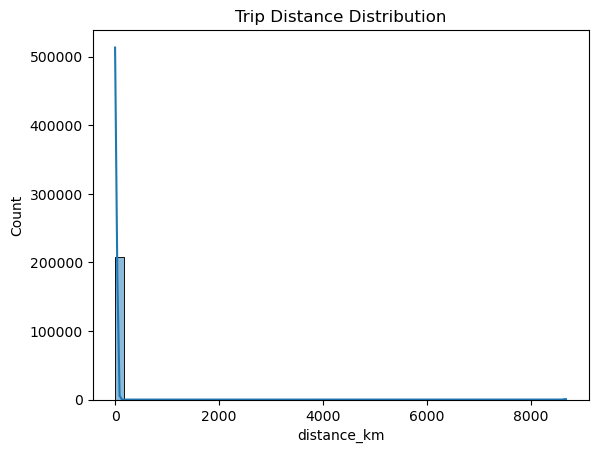

In [174]:
sns.histplot(feature_df['distance_km'], bins=50, kde=True)
plt.title("Trip Distance Distribution")
plt.show()

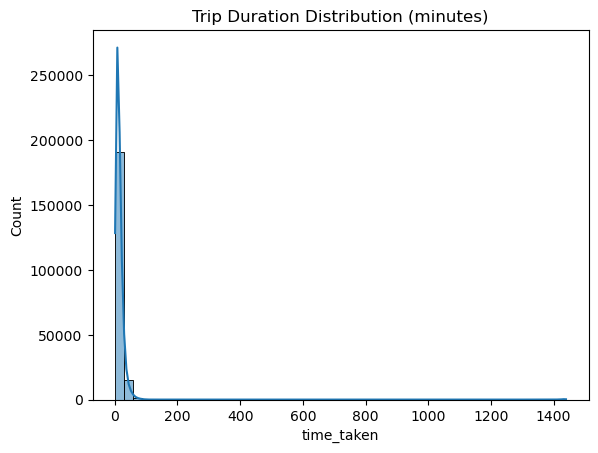

In [175]:
sns.histplot(feature_df['time_taken'], bins=50, kde=True)
plt.title("Trip Duration Distribution (minutes)")
plt.show()

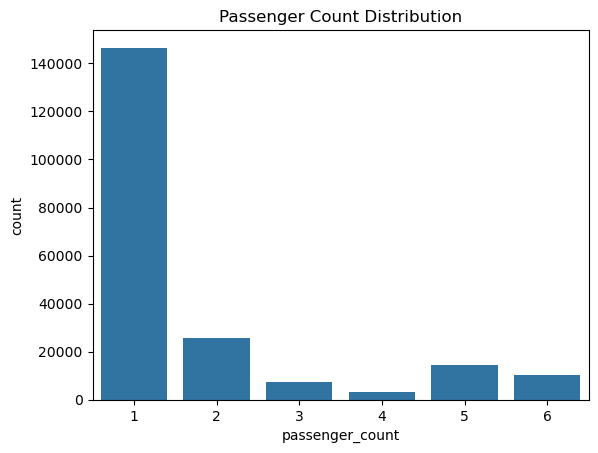

In [176]:
sns.countplot(x='passenger_count', data=feature_df)
plt.title("Passenger Count Distribution")
plt.show()

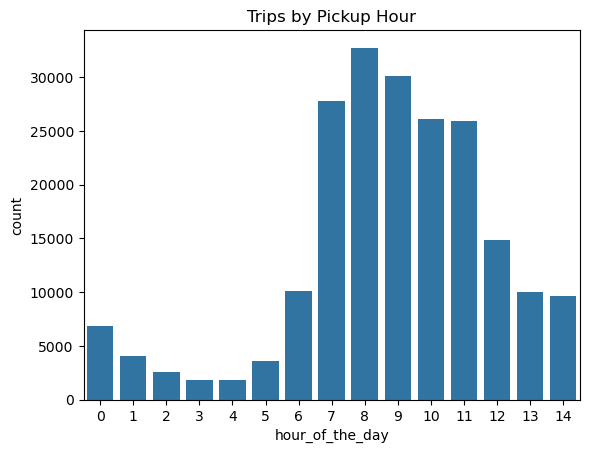

In [177]:
sns.countplot(x='hour_of_the_day', data=feature_df)
plt.title("Trips by Pickup Hour")
plt.show()

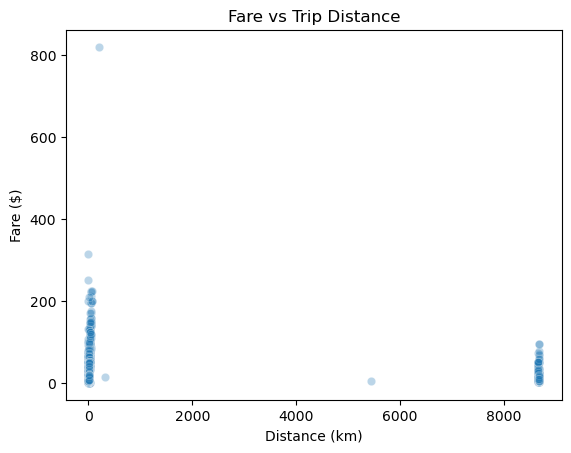

In [178]:
sns.scatterplot(x='distance_km', y='fare_amount', data=feature_df, alpha=0.3)
plt.title("Fare vs Trip Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare ($)")
plt.show()

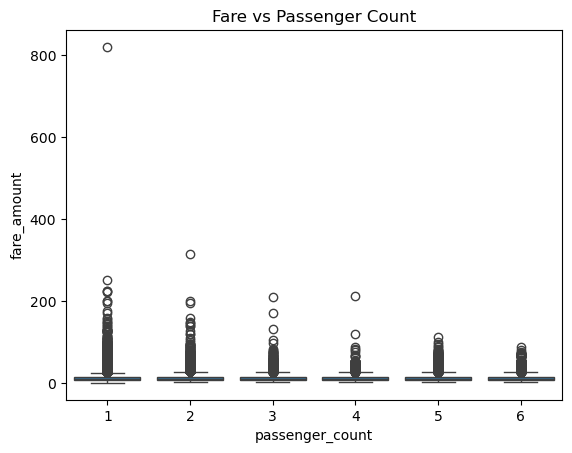

In [179]:
sns.boxplot(x='passenger_count', y='fare_amount', data=feature_df)
plt.title("Fare vs Passenger Count")
plt.show()

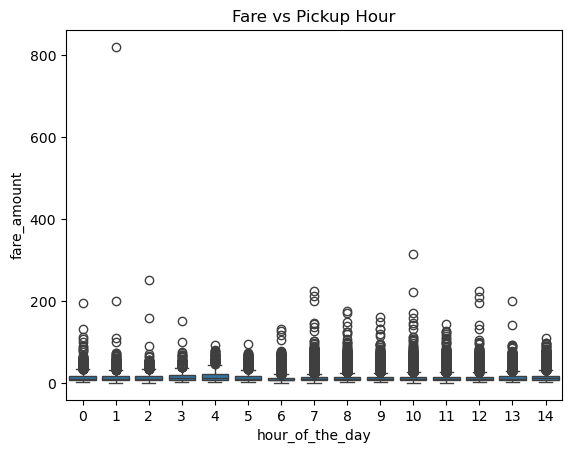

In [180]:
sns.boxplot(x='hour_of_the_day', y='fare_amount', data=feature_df)
plt.title("Fare vs Pickup Hour")
plt.show()

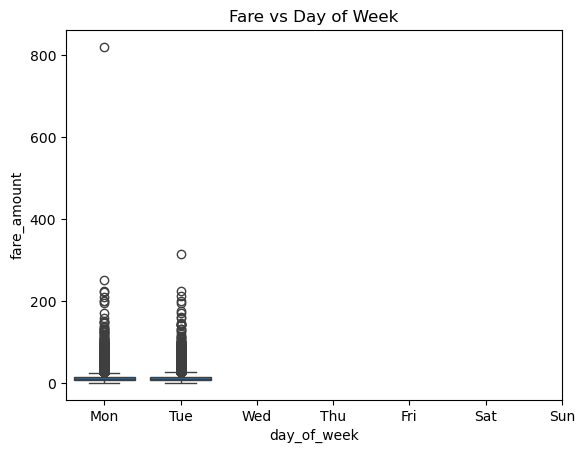

In [181]:
sns.boxplot(x='day_of_week', y='fare_amount', data=feature_df)
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Fare vs Day of Week")
plt.show()

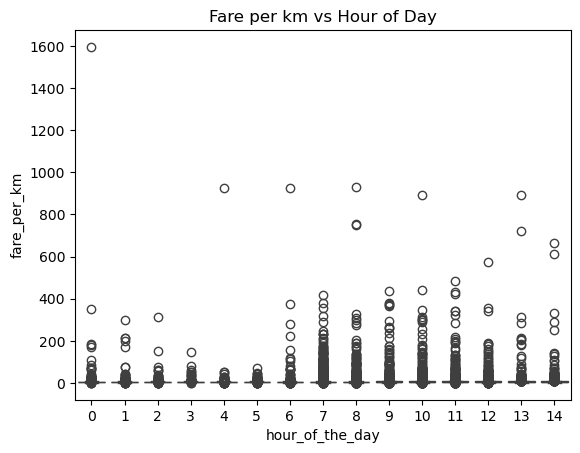

In [182]:
feature_df['fare_per_km'] = feature_df['fare_amount'] / feature_df['distance_km']
feature_df['fare_per_min'] = feature_df['fare_amount'] / feature_df['time_taken']

sns.boxplot(x='hour_of_the_day', y='fare_per_km', data=feature_df)
plt.title("Fare per km vs Hour of Day")
plt.show()


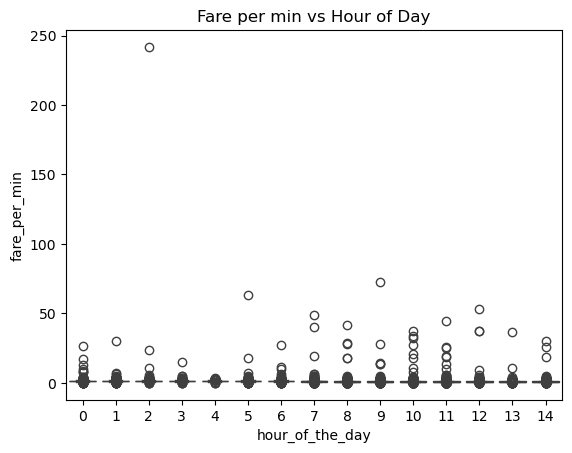

In [183]:
sns.boxplot(x='hour_of_the_day', y='fare_per_min', data=feature_df)
plt.title("Fare per min vs Hour of Day")
plt.show()

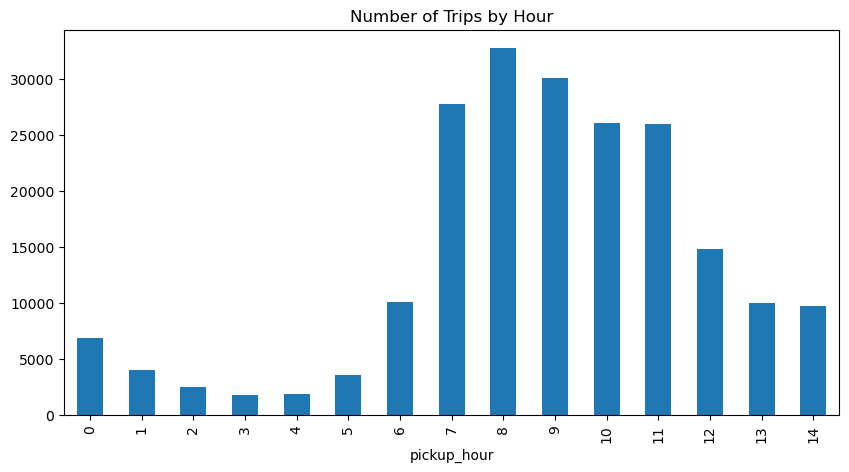

In [184]:
feature_df['pickup_hour'] = feature_df['hour_of_the_day']
trips_per_hour = feature_df.groupby('pickup_hour').size()
trips_per_hour.plot(kind='bar', figsize=(10,5))
plt.title("Number of Trips by Hour")
plt.show()

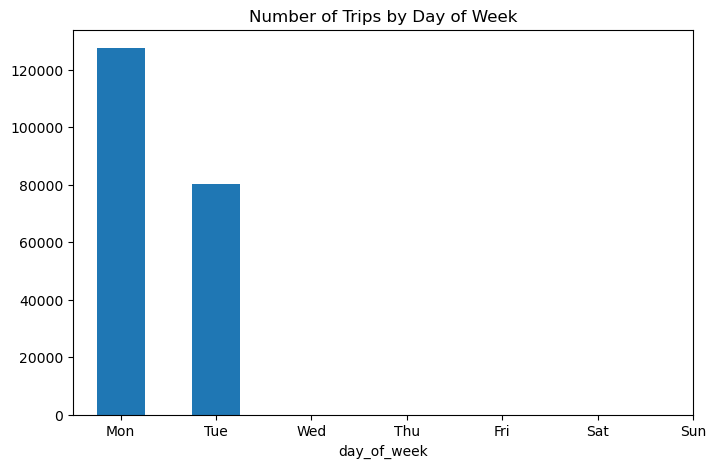

In [185]:
trips_per_day = feature_df.groupby('day_of_week').size()
trips_per_day.plot(kind='bar', figsize=(8,5))
plt.title("Number of Trips by Day of Week")
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.show()